# Understanding Linear Regression

This notebook teaches **linear regression** using NBA player game data from **S25.csv**. You'll learn when to use it, its assumptions, pros and cons, failure cases, and see it in action on real data.

## 1. When to Use Linear Regression

Use **linear regression** when:

- **Target is continuous** — You're predicting a numeric value (e.g., points per game, salary, temperature), not a category.
- **Relationship is (roughly) linear** — Changes in features correspond to roughly proportional changes in the target.
- **Interpretability matters** — You want to say "one more FGA is associated with ~X more points," and need coefficients you can explain.
- **Baseline or simple model** — You need a fast, interpretable baseline before trying more complex models.
- **Few features or low dimensionality** — Works well when the number of predictors is modest and relationships are not highly nonlinear.

**Example with our data:** Predicting **player points (PTS)** from minutes played (MIN), field goal attempts (FGA), and usage (USG_PCT) is a natural fit — more minutes and shots tend to mean more points in a roughly linear way.

## 2. Assumptions of Linear Regression

For **valid inference** (confidence intervals, p-values) and **best predictions**, the model assumes:

| Assumption | Meaning | How to check |
|------------|--------|----------------|
| **Linearity** | The mean of Y is a linear function of X (e.g. $$\mathbb{E}[Y] = \beta_0 + \beta_1 X_1 + \cdots + \beta_k X_k$$). | Plot residuals vs each predictor; they should be centered around 0 with no clear curve. |
| **Independence** | Observations are independent (e.g. no repeated measures per player without accounting for it). | Know your data; use clustered/robust SE or mixed models if you have repeated observations. |
| **Homoscedasticity** | Residual variance is constant across fitted values. | Plot residuals vs fitted; look for a random band, not a funnel. |
| **Normality of residuals** | For small samples, residuals are approximately normal (for hypothesis tests). | Q-Q plot of residuals; points should follow the diagonal line. |
| **No perfect multicollinearity** | Predictors are not exact linear combinations of each other. | Correlation matrix; VIF; drop or combine highly correlated predictors. |

We'll check several of these after fitting the model on S25 data.

## 3. Pros and Cons

### Pros
- **Simple and interpretable** — Coefficients have a direct meaning (change in Y per unit change in X).
- **Fast to fit** — Closed-form solution (no iterative optimization needed for OLS).
- **Low overfitting risk** when feature count is small relative to sample size.
- **Well-understood theory** — Confidence intervals, p-values, and diagnostics are standard.
- **Baseline** — Good first model to compare against more complex ones.

### Cons
- **Assumes linearity** — Poor when relationships are curved or interactive unless you add terms (e.g. polynomials, interactions).
- **Sensitive to outliers** — One extreme point can pull the line.
- **Cannot model discrete outcomes** (e.g. win/loss) without switching to logistic regression.
- **Multicollinearity** can make coefficients unstable and hard to interpret.
- **No automatic feature selection** — You must choose and possibly transform predictors.

## 4. Failure Cases

Linear regression can **fail or mislead** when:

1. **Relationship is nonlinear** — e.g. performance vs. age (inverted U); a straight line underfits.
2. **Outliers dominate** — A few extreme games (e.g. 0 minutes or 50 points in 5 minutes) can skew the line.
3. **Heteroscedasticity** — Variance of points might be larger for high-usage players; CIs and p-values become unreliable.
4. **Multicollinearity** — e.g. FGA, FGM, and FG_PCT are related; coefficients become unstable.
5. **Wrong scale** — Predicting a bounded outcome (e.g. FG%) with a model that can predict &lt; 0 or &gt; 1.
6. **Confounding** — Important variables omitted (e.g. opponent strength); coefficients can be biased.
7. **Non-independence** — Many rows per player; standard errors are too small if we ignore clustering.

We'll demonstrate a couple of these (e.g. outlier impact, residual plots) in the code below.

---
## 5. Load and Explore S25 Data

We'll load the CSV and pick a few numeric columns to predict **PTS** (points) from **MIN** (minutes), **FGA** (field goal attempts), and **USG_PCT** (usage rate).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

# Load data (notebook is in Machine Learning/, CSV in repo root)
df = pd.read_csv('../S25.csv')
print("Shape:", df.shape)
print("\nColumns (first 30):", list(df.columns[:30]))

Shape: (26306, 188)

Columns (first 30): ['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'PLAYER_NAME', 'PLAYER_ID', 'MATCHUP', 'TEAM_ABBREVIATION', 'TEAM_ID', 'OPP_ABBREVIATION', 'HOME_GAME', 'GAME_ID', 'GAME_DATE', 'WL', 'PTS', 'AST', 'REB', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'STL', 'BLK', 'TOV']


In [15]:
# Select features and target; drop rows with missing values in these columns
target = 'PTS'
features = ['MIN', 'FGA', 'USG_PCT']
cols = [target] + features
sub = df[cols].dropna()
print("Rows after dropping NaN:", len(sub))
print(sub.describe())

Rows after dropping NaN: 26306
                PTS           MIN           FGA       USG_PCT
count  26306.000000  26306.000000  26306.000000  26306.000000
mean      10.644340     22.565439      8.345130      0.181521
std        8.798205     10.842895      6.022891      0.087843
min        0.000000      0.000000      0.000000      0.000000
25%        4.000000     14.770000      4.000000      0.125000
50%        9.000000     23.700000      7.000000      0.176000
75%       16.000000     31.330000     12.000000      0.233000
max       61.000000     53.170000     39.000000      1.000000


### Quick look at relationships (linearity)

Scatter of **PTS vs FGA** — we expect a roughly linear, positive relationship.

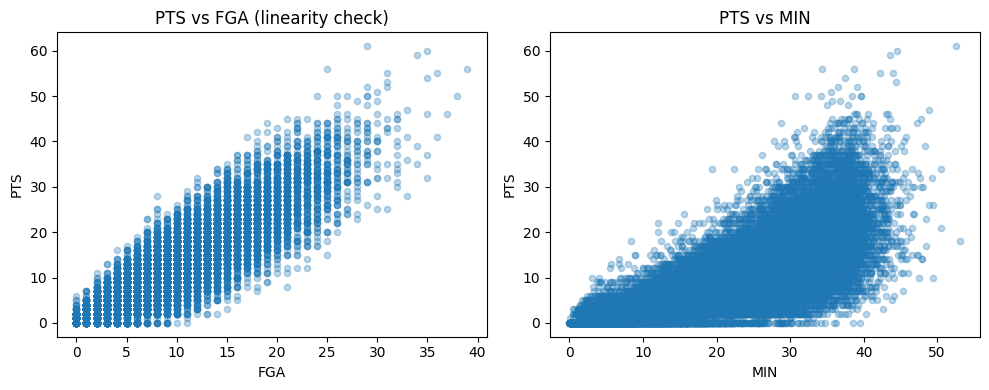

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sub.plot.scatter('FGA', 'PTS', alpha=0.3, ax=ax[0])
ax[0].set_title('PTS vs FGA (linearity check)')
sub.plot.scatter('MIN', 'PTS', alpha=0.3, ax=ax[1])
ax[1].set_title('PTS vs MIN')
plt.tight_layout()
plt.show()

---
## 6. Fit Linear Regression

We fit: **PTS = β₀ + β₁·MIN + β₂·FGA + β₃·USG_PCT**

In [17]:
X = sub[features]
y = sub[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Coefficients (interpretation: change in PTS per 1-unit change in feature):")
for name, coef in zip(features, model.coef_):
    print(f"  {name}: {coef:.3f}")
print(f"  Intercept: {model.intercept_:.3f}")
print("\nTrain R²:", r2_score(y_train, y_pred_train))
print("Test  R²:", r2_score(y_test, y_pred_test))
print("Test  RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

Coefficients (interpretation: change in PTS per 1-unit change in feature):
  MIN: 0.104
  FGA: 1.087
  USG_PCT: 7.012
  Intercept: -2.055

Train R²: 0.8025427308633486
Test  R²: 0.8042437689689533
Test  RMSE: 3.9576657615552344


### Model Evaluation Metrics

Model evaluation tells you how well your model performs on new, unseen data.

For linear regression, the most common metrics are RMSE and R².

---

### RMSE (Root Mean Squared Error)

RMSE measures the average size of your prediction errors.

It compares:
- the true values
- the predicted values

Because the errors are squared first, larger mistakes get punished more.

#### Interpretation

- Lower RMSE is better
- RMSE is in the same unit as the target variable

#### Example

If you are predicting house prices and your RMSE is 25,000, your model is usually off by about $25,000.

#### Formula

RMSE = sqrt(mean((y_true - y_pred)^2))

#### When to use RMSE

Use RMSE when:
- you care about prediction error size
- large errors should matter more

---

### R² (Coefficient of Determination)

R² tells you how much of the variation in the target variable your model explains.

#### Range

- 1 means the model explains all of the variance
- 0 means the model explains none of the variance
- Negative means the model is worse than just predicting the mean

#### Interpretation

- Higher R² is better
- R² shows how well the model fits the data

#### Example

If R² = 0.82, the model explains 82% of the variance in the target.

#### Formula

R² = 1 - (SS_res / SS_total)

#### When to use R²

Use R² when:
- you want to measure how well the model explains the data
- you want a simple summary of model fit

---
## 7. Checking Assumptions (Residuals)

- **Residuals vs fitted** — Should be a random band (homoscedasticity, no clear nonlinearity).
- **Q-Q plot** — Residuals should follow the diagonal line (normality).

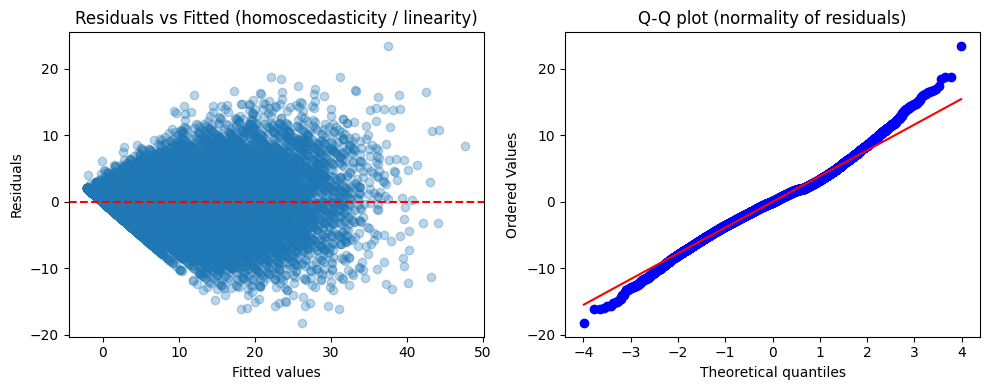

In [18]:
residuals = y_train - y_pred_train
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(y_pred_train, residuals, alpha=0.3)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residuals vs Fitted (homoscedasticity / linearity)')
stats.probplot(residuals, dist="norm", plot=ax[1])
ax[1].set_title('Q-Q plot (normality of residuals)')
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning in Linear Regression

Hyperparameters are settings you choose before training the model.

They are different from model parameters.

- Parameters are learned from the data, like coefficients and the intercept
- Hyperparameters are choices you make, like how much regularization to apply

For basic linear regression, there are not many hyperparameters.

But for regularized linear regression models, hyperparameters matter a lot.

---

### Why Hyperparameter Tuning Matters

Hyperparameter tuning helps you control how simple or complex the model becomes.

This affects:

- underfitting
- overfitting
- generalization to new data

The goal is to find settings that perform well on unseen data.

---

### Important Hyperparameters in Linear Regression Models

#### 1. alpha in Ridge Regression

Ridge regression adds a penalty to large coefficient values.

`alpha` controls how strong that penalty is.

- Small alpha means less regularization
- Large alpha means more regularization

Effect:
- helps reduce overfitting
- shrinks coefficients
- very large alpha can make the model too simple

---

#### 2. alpha in Lasso Regression

Lasso regression also adds regularization.

Its `alpha` controls penalty strength too.

- Small alpha means less regularization
- Large alpha means more regularization

Effect:
- can shrink some coefficients all the way to zero
- acts like feature selection
- too much regularization can remove useful features

---

#### 3. l1_ratio in Elastic Net

Elastic Net combines Ridge and Lasso.

`l1_ratio` controls the mix between them.

- `l1_ratio = 0` means more like Ridge
- `l1_ratio = 1` means more like Lasso
- values in between blend both

Effect:
- balances coefficient shrinkage and feature selection

---

### What Tuning Usually Looks Like

You try different values for the hyperparameters and compare performance on validation data.

Common approach:

- choose a set of values
- use cross-validation
- pick the values with the best score

---

### Practical Rule

For linear regression models, the main knob is usually regularization strength.

The most important thing to know is this:

- higher regularization usually makes the model simpler
- lower regularization lets the model fit the training data more closely

You tune these settings to improve performance on new data, not just training data.

In [19]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

X = sub[features]
y = sub[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

alphas = [0.01, 0.1, 1.0]

print("Ridge Regression Hyperparameter Tuning")
print("-" * 50)

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    print(f"alpha = {alpha}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²:  {test_r2:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print()

print("Lasso Regression Hyperparameter Tuning")
print("-" * 50)

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    print(f"alpha = {alpha}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²:  {test_r2:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print()

Ridge Regression Hyperparameter Tuning
--------------------------------------------------
alpha = 0.01
  Train R²: 0.8025
  Test R²:  0.8042
  Test RMSE: 3.9577

alpha = 0.1
  Train R²: 0.8025
  Test R²:  0.8042
  Test RMSE: 3.9577

alpha = 1.0
  Train R²: 0.8025
  Test R²:  0.8042
  Test RMSE: 3.9577

Lasso Regression Hyperparameter Tuning
--------------------------------------------------
alpha = 0.01
  Train R²: 0.8022
  Test R²:  0.8038
  Test RMSE: 3.9622

alpha = 0.1
  Train R²: 0.8003
  Test R²:  0.8019
  Test RMSE: 3.9814

alpha = 1.0
  Train R²: 0.7999
  Test R²:  0.8009
  Test RMSE: 3.9914



### How to interpret the results

Look at the test metrics.

- If `alpha` is too small, the model may overfit
- If `alpha` is too large, the model may underfit
- A good `alpha` gives stronger test performance and lower test RMSE

## 9. Practical Implementation in scikit-learn

That includes:

- splitting data into training and testing sets
- fitting a model
- making predictions
- evaluating results
- using pipelines
- using cross-validation

These tools help you build models that are clean, repeatable, and easier to trust.

---

### Train and Test Split

A train and test split helps you measure how well your model performs on unseen data.

- the training set is used to fit the model
- the test set is used to evaluate it

This is one of the first steps in a real machine learning workflow.

---

### Pipelines

A pipeline lets you chain preprocessing steps and the model into one object.

This is useful because it keeps your workflow organized and prevents mistakes like data leakage.

For example, a pipeline can:

- scale the features
- fit the linear regression model
- apply the same steps automatically at prediction time

Pipelines are important when your data needs preprocessing before modeling.

---

### Cross-Validation

Cross-validation gives a more reliable estimate of model performance.

Instead of evaluating the model on just one train and test split, it trains and evaluates the model across multiple splits.

This helps you:

- reduce dependence on one random split
- get a more stable estimate of performance
- compare models more confidently

A common choice is 5-fold cross-validation.


In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Select features and target
X = sub[features]
y = sub[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build a pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Evaluate performance
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

# Cross-validation
cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nCross-Validation R² Scores:", cv_scores)
print("Average CV R²:", cv_scores.mean())

Train R²: 0.8025427308633486
Test R²: 0.8042437689689533
Test RMSE: 3.9576657615552344

Cross-Validation R² Scores: [0.80843543 0.79770516 0.80987733 0.80875653 0.78800615]
Average CV R²: 0.8025561209746694


---
## 9. Failure Case: Outliers

Adding a few **extreme rows** (e.g. 0 minutes, 0 points; or 48 minutes, 60 points) shows how the regression line can be pulled. We compare coefficients and R² with and without outliers.

In [21]:
# Add synthetic outliers: a few extreme points
outliers = pd.DataFrame({
    'PTS': [0, 0, 60, 55],
    'MIN': [0.5, 1, 48, 48],
    'FGA': [0, 1, 35, 30],
    'USG_PCT': [0.05, 0.1, 0.45, 0.42]
})
sub_contaminated = pd.concat([sub, outliers], ignore_index=True)
X_out = sub_contaminated[features]
y_out = sub_contaminated[target]

model_out = LinearRegression()
model_out.fit(X_out, y_out)

print("Coefficients WITHOUT outliers (original model):")
for name, coef in zip(features, model.coef_):
    print(f"  {name}: {coef:.3f}")
print("\nCoefficients WITH outliers (contaminated):")
for name, coef in zip(features, model_out.coef_):
    print(f"  {name}: {coef:.3f}")
print("\n→ A few extreme points can shift the line (failure case: sensitivity to outliers).")

Coefficients WITHOUT outliers (original model):
  MIN: 0.079
  FGA: 1.160
  USG_PCT: 0.000

Coefficients WITH outliers (contaminated):
  MIN: 0.103
  FGA: 1.093
  USG_PCT: 7.107

→ A few extreme points can shift the line (failure case: sensitivity to outliers).


## 10. Bias-Variance Tradeoff

The bias-variance tradeoff helps explain why a model performs well or poorly.

It is one of the most important ideas in machine learning because it connects:

- model complexity
- underfitting
- overfitting
- generalization

This concept comes up often in interviews because it shows whether you understand how models behave.

---

### Bias

Bias is error caused by a model being too simple.

A high-bias model makes strong assumptions and cannot capture the real pattern in the data.

This usually leads to underfitting.

Signs of high bias:

- low training performance
- low test performance
- model is too simple to learn the relationship

Example:

A linear model trying to fit data with a curved pattern.

---

### Variance

Variance is error caused by a model being too sensitive to the training data.

A high-variance model learns the training data too closely, including noise.

This usually leads to overfitting.

Signs of high variance:

- very high training performance
- much worse test performance
- model does not generalize well

Example:

A model that memorizes the training data but performs poorly on new data.

---

### The Tradeoff

As model complexity increases:

- bias usually decreases
- variance usually increases

As model complexity decreases:

- bias usually increases
- variance usually decreases

The goal is to find a balance where the model is flexible enough to learn real patterns, but simple enough to generalize well.

---

### In Linear Regression

Even linear regression can face this tradeoff.

Examples:

- too few useful features can lead to high bias
- too many noisy features can lead to high variance
- too little regularization can overfit
- too much regularization can underfit

This is why tuning and evaluation matter.

---

### How to Recognize It

You can often spot bias or variance by comparing train and test performance.

High bias pattern:

- low Train R²
- low Test R²

High variance pattern:

- high Train R²
- lower Test R²

Good balance:

- strong Train R²
- similar Test R²

---

### Why it matters

The bias-variance tradeoff helps you decide:

- whether the model is too simple
- whether the model is too complex
- whether you need more features
- whether you need regularization
- whether your model is likely to generalize well

It gives you a way to diagnose model behavior instead of guessing.

## 11. Feature Engineering Basics

Models do not work on clean data by default. Real datasets usually contain missing values, categorical variables, and features on very different scales.

Feature engineering is the process of preparing raw data so a model can learn from it effectively.

For linear regression, this step matters a lot because the model assumes the input features are numeric and well-structured.

---

### Encoding Categorical Variables

Linear regression cannot work directly with text categories like:

- team name
- position
- opponent
- home or away

You need to convert these categories into numbers.

A common method is one-hot encoding.

Example:

If `position` has values:

- Guard
- Forward
- Center

One-hot encoding turns this into separate columns such as:

- position_Guard
- position_Forward
- position_Center

This lets the model learn a separate effect for each category.

---

### Scaling Features

Some features may have very different ranges.

Example:

- minutes played might range from 0 to 48
- salary might range from thousands to millions

Scaling makes features more comparable by putting them on a similar scale.

This is especially useful for models that are sensitive to feature size, such as:

- Ridge
- Lasso
- Elastic Net

A common method is standardization:

Standardized value = (x - mean) / standard deviation

This centers the feature around 0 and scales it to have unit variance.

---

### Handling Missing Values

Real data often has missing values, also called nulls.

Examples:

- a player missed games
- a stat was not recorded
- a field was left blank

Most models cannot handle missing values directly, so you need to deal with them first.

Common strategies:

- fill with the mean
- fill with the median
- fill with the most frequent value
- drop rows or columns when appropriate

The best choice depends on the data and the meaning of the missing values.

---

### Why this matters

Good feature engineering helps the model learn useful patterns.

Poor feature engineering can hurt performance, even if the model itself is correct.

In practice, feature engineering often matters as much as the model choice.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

# Example feature groups
numeric_features = ["MIN", "USG_PCT", "FG_PCT"]
categorical_features = ["HOME_GAME", "OPPONENT"]

# Preprocessing for numeric columns
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical columns
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both into one preprocessing step
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Full pipeline
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Fit the model
model_pipeline.fit(X_train, y_train)

# Predict
y_pred = model_pipeline.predict(X_test)

---
## Summary

| Topic | Takeaway |
|-------|----------|
| **When to use** | Use linear regression when your target is continuous, the relationship is roughly linear, and you want interpretable feature effects. |
| **Assumptions** | Linear relationship, independent observations, constant error variance, roughly normal residuals, and no perfect multicollinearity. |
| **Model evaluation** | Use **RMSE** to measure prediction error size and **R²** to measure how much variance the model explains. |
| **Hyperparameter tuning** | Basic linear regression has few tuning knobs, but regularized versions like Ridge and Lasso use hyperparameters such as `alpha` to control model complexity. |
| **Practical implementation** | In scikit-learn, you should know how to do train/test splits, pipelines, preprocessing, and cross-validation. |
| **Bias-variance tradeoff** | A model that is too simple underfits, high bias. A model that is too complex overfits, high variance. The goal is to balance both. |
| **Feature engineering** | Models need clean inputs. Common steps include handling missing values, scaling numeric features, and encoding categorical variables. |
| **Pros** | Simple, interpretable, fast, and a strong baseline model. |
| **Cons** | Assumes linearity, can be sensitive to outliers, and may perform poorly when patterns are more complex. |
| **Failure cases** | Nonlinear relationships, outliers, heteroscedasticity, multicollinearity, omitted variables, and dependent observations. |

On S25 data, linear regression gives an interpretable model for **PTS** using **MIN**, **FGA**, and **USG_PCT**. It is a strong baseline, but you should still evaluate performance with **RMSE** and **R²**, inspect residual plots, and consider regularized methods like Ridge or Lasso if assumptions break or overfitting appears.